# KLA - Baseline NAFNet Training

Degraded Input -> Normalisation -> Degradataion Encoder -> NAFNet -> Charbonnier loss

In [1]:
import os
import sys
sys.path.append('..')
import time
import dataclasses
from pathlib import Path
from typing import Callable

import jax
import jax.numpy as jnp
import numpy as np
import optax
import orbax.checkpoint as ocp
import grain
from flax import nnx
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm


In [2]:
TRAIN_PATH = "../train"
TEST_PATH = "../NoisyLR"

TRAIN_LR_PATH = os.path.join(TRAIN_PATH, "NoisyLR")
TEST_LR_PATH = TEST_PATH
TRAIN_GT_PATH = os.path.join(TRAIN_PATH, "GT")


In [3]:
@dataclasses.dataclass
class TrainConfig:
    train_noisy_dir: str
    train_gt_dir: str
    batch_size: int = 8
    worker_count: int = 1
    seed: int = 42

    in_channels: int = 1
    out_channels: int = 1
    hidden_dim: int = 32
    num_blocks: int = 4
    upsample_scale: int = 2

    deg_hidden_dim: int = 16
    deg_embed_dim: int = 8

    normalization: str = "asinh"

    learning_rate: float = 1e-3
    weight_decay: float = 3e-4
    grad_clip_norm: float = 1.0

    num_epochs: int = 100
    val_split: float = 0.1

    ckpt_dir: str = "checkpoints"
    ckpt_every_epochs: int = 5
    max_to_keep: int = 5

    log_every_steps: int = 20
    loss_func: str = "Huber"


cfg = TrainConfig(
    train_noisy_dir=TRAIN_LR_PATH,
    train_gt_dir=TRAIN_GT_PATH,
    batch_size=4,
    hidden_dim=32,
    num_blocks=8,
    num_epochs=30,
    ckpt_dir="./checkpoints",
    ckpt_every_epochs=5,
)


In [4]:
from dataloader import create_src_dataloader


In [5]:
EPS = 1e-6


def zscore_normalize(x: jax.Array, axis=None, eps: float = EPS) -> jax.Array:
    mean = jnp.mean(x, axis=axis, keepdims=True)
    std = jnp.std(x, axis=axis, keepdims=True)
    return (x - mean) / (std + eps)


def zscore_denormalize(x_norm: jax.Array, mean: jax.Array, std: jax.Array, eps: float = EPS) -> jax.Array:
    return x_norm * (std + eps) + mean


def asinh_normalize(x: jax.Array, axis=None, eps: float = EPS) -> jax.Array:
    median = jnp.median(x, axis=axis, keepdims=True)
    q75 = jnp.quantile(x, 0.75, axis=axis, keepdims=True)
    q25 = jnp.quantile(x, 0.25, axis=axis, keepdims=True)
    iqr = q75 - q25
    return jnp.arcsinh((x - median) / (iqr + eps))


def asinh_denormalize(x_norm: jax.Array, median: jax.Array, iqr: jax.Array, eps: float = EPS) -> jax.Array:
    return jnp.sinh(x_norm) * (iqr + eps) + median


# Registry so the train script can select strategy by name from config,
# without importing every function individually.
NORMALIZERS: dict[str, Callable[..., jax.Array]] = {
    "zscore": zscore_normalize,
    "asinh": asinh_normalize,
    "none": lambda x, **kwargs: x,
}


def get_normalizer(name: str) -> Callable[..., jax.Array]:
    if name not in NORMALIZERS:
        raise ValueError(f"Unknown normalizer '{name}'. Options: {list(NORMALIZERS)}")
    return NORMALIZERS[name]


In [6]:
from model_util import *
from finetune_pipeline import RestorationPipeline_Finetune, load_pretrained_nafnet
from train_utils import *


In [7]:
# ── File listing + train/val split ──────────────────────────────────────

all_noisy = sorted(Path(cfg.train_noisy_dir).glob("*.npy"))
all_gt    = sorted(Path(cfg.train_gt_dir).glob("*.npy"))
assert len(all_noisy) == len(all_gt), (
    f"Mismatch: {len(all_noisy)} noisy files vs {len(all_gt)} GT files"
)

train_noisy, val_noisy, train_gt, val_gt = train_test_split(
    all_noisy, all_gt,
    test_size=cfg.val_split, random_state=cfg.seed,
)

# ── Build dataloaders ───────────────────────────────────────────────────

train_src, train_loader = create_src_dataloader(
    train_noisy, train_gt,
    batch_size=cfg.batch_size, worker_count=cfg.worker_count,
    seed=cfg.seed, shuffle=True, augment=True,
)

val_src, val_loader = create_src_dataloader(
    val_noisy, val_gt,
    batch_size=cfg.batch_size, worker_count=cfg.worker_count,
    seed=cfg.seed + 1, shuffle=False, augment=False,
)

train_steps_per_epoch = len(train_src) // cfg.batch_size
val_steps_per_epoch   = len(val_src) // cfg.batch_size

print(f"Train: {len(train_src)} samples → {train_steps_per_epoch} steps/epoch")
print(f"Val:   {len(val_src)} samples → {val_steps_per_epoch} steps/epoch")


Train: 2880 samples → 720 steps/epoch
Val:   320 samples → 80 steps/epoch


In [8]:
def build_checkpoint_manager(ckpt_dir, max_to_keep=5):
    options = ocp.CheckpointManagerOptions(
        max_to_keep=max_to_keep,
        save_interval_steps=1,  
        create=True,
        enable_async_checkpointing=True,
    )
    ckpt_dir = Path(ckpt_dir).resolve()
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    return ocp.CheckpointManager(str(ckpt_dir), options=options)


def save_checkpoint(manager, step, model, optimizer_pretrained, optimizer_new, optimizer_proj, epoch, train_loss):
    _, model_state = nnx.split(model)
    _, opt_pretrained_state = nnx.split(optimizer_pretrained)
    _, opt_new_state = nnx.split(optimizer_new)
    _, opt_proj_state = nnx.split(optimizer_proj)
    metadata = {"epoch": epoch, "step": step, "train_loss": float(train_loss)}

    manager.save(
        step,
        args=ocp.args.Composite(
            model_state=ocp.args.StandardSave(model_state),
            opt_pretrained_state=ocp.args.StandardSave(opt_pretrained_state),
            opt_new_state=ocp.args.StandardSave(opt_new_state),
            opt_proj_state=ocp.args.StandardSave(opt_proj_state),
            metadata=ocp.args.JsonSave(metadata),
        ),
    )


def restore_checkpoint(manager, step, model, optimizer_pretrained, optimizer_new, optimizer_proj):
    _, abstract_model_state = nnx.split(nnx.eval_shape(lambda: model))
    _, abstract_opt_pretrained = nnx.split(nnx.eval_shape(lambda: optimizer_pretrained))
    _, abstract_opt_new = nnx.split(nnx.eval_shape(lambda: optimizer_new))
    _, abstract_opt_proj = nnx.split(nnx.eval_shape(lambda: optimizer_proj))

    restored = manager.restore(
        step,
        args=ocp.args.Composite(
            model_state=ocp.args.StandardRestore(abstract_model_state),
            opt_pretrained_state=ocp.args.StandardRestore(abstract_opt_pretrained),
            opt_new_state=ocp.args.StandardRestore(abstract_opt_new),
            opt_proj_state=ocp.args.StandardRestore(abstract_opt_proj),
            metadata=ocp.args.JsonRestore(),
        ),
    )
    nnx.update(model, restored.model_state)
    nnx.update(optimizer_pretrained, restored.opt_pretrained_state)
    nnx.update(optimizer_new, restored.opt_new_state)
    nnx.update(optimizer_proj, restored.opt_proj_state)


In [9]:

rngs = nnx.Rngs(cfg.seed)
model = RestorationPipeline_Finetune(rngs=rngs)
# Load pretrained weights
load_pretrained_nafnet(model, "nafnet_pretrained.msgpack")

warmup = 2000
total_train_steps = train_steps_per_epoch * cfg.num_epochs

# Separate schedules
schedule_pretrained = optax.warmup_cosine_decay_schedule(
    init_value=0.0, peak_value=cfg.learning_rate * 0.1, # 10x smaller LR for pretrained NAFNet
    warmup_steps=warmup, decay_steps=total_train_steps - warmup, end_value=1e-6,
)

schedule_new = optax.warmup_cosine_decay_schedule(
    init_value=0.0, peak_value=cfg.learning_rate,
    warmup_steps=warmup, decay_steps=total_train_steps - warmup, end_value=1e-6,
)

# In NNX, we can use nnx.MultiOptimizer directly in recent versions,
# but we can also just create multiple optimizers.
# Let's create two optimizers!
optimizer_pretrained = nnx.Optimizer(
    model.nafnet,
    optax.chain(
        optax.clip_by_global_norm(cfg.grad_clip_norm),
        optax.adamw(learning_rate=schedule_pretrained, weight_decay=cfg.weight_decay),
    ),
    wrt=nnx.Param,
)

optimizer_new = nnx.Optimizer(
    model.tail_blocks,
    optax.chain(
        optax.clip_by_global_norm(cfg.grad_clip_norm),
        optax.adamw(learning_rate=schedule_new, weight_decay=cfg.weight_decay),
    ),
    wrt=nnx.Param,
)

optimizer_proj = nnx.Optimizer(
    model.final_proj,
    optax.chain(
        optax.clip_by_global_norm(cfg.grad_clip_norm),
        optax.adamw(learning_rate=schedule_new, weight_decay=cfg.weight_decay),
    ),
    wrt=nnx.Param,
)

normalizer_fn = asinh_normalize

ckpt_manager = build_checkpoint_manager(cfg.ckpt_dir, max_to_keep=cfg.max_to_keep)
print(f"[hardware] backend={jax.default_backend()} devices={jax.devices()}")
print(f"[schedule] warmup={warmup}  total_steps={total_train_steps}")


Pre-trained weights successfully loaded into NAFNet component!
[hardware] backend=gpu devices=[CudaDevice(id=0)]
[schedule] warmup=2000  total_steps=21600


In [10]:
@nnx.jit
def train_step_finetune(model, opt_pretrained, opt_new, opt_proj, x, gt):
    def loss_fn(m):
        pred = m(x)
        # Use whatever loss the baseline uses, let's assume mixed_loss
        loss = mixed_loss(pred, gt)
        return loss
    
    loss, grads = nnx.value_and_grad(loss_fn)(model)
    
    # Update respective parts
    opt_pretrained.update(model.nafnet,grads.nafnet)
    opt_new.update(model.tail_blocks,grads.tail_blocks)
    opt_proj.update(model.final_proj,grads.final_proj)
    
    return loss

@nnx.jit
def val_step_finetune(model, x, gt):
    pred = model(x)
    loss = mixed_loss(pred, gt)
    return loss



In [11]:

global_step = 0

for epoch in range(cfg.num_epochs):
    epoch_start = time.time()
    train_iter = iter(train_loader)
    val_iter   = iter(val_loader)
    # ── Train ─────────────────────────────────────────────────────────
    model.train()
    epoch_train_losses = []
    pbar = tqdm(range(train_steps_per_epoch), desc=f"Epoch {epoch:03d} [train]", leave=False)
    for step_in_epoch in pbar:
        raw_batch = to_device(next(train_iter))

        # --- preprocessing (outside JIT) ---
        noisy = raw_batch["noisy_lr"].astype(jnp.float32)

        gt    = raw_batch["gt"].astype(jnp.float32)
        x_norm = normalizer_fn(noisy, axis=(1, 2))

        loss = train_step_finetune(model, optimizer_pretrained, optimizer_new, optimizer_proj, x_norm, gt)
        epoch_train_losses.append(float(loss))
        global_step += 1

        pbar.set_postfix(loss=f"{float(loss):.5f}")

    train_loss_mean = float(np.mean(epoch_train_losses))

    # ── Validate ──────────────────────────────────────────────────────
    model.eval()
    epoch_val_losses = []
    pbar_val = tqdm(range(val_steps_per_epoch), desc=f"Epoch {epoch:03d} [val]  ", leave=False)
    for _ in pbar_val:
        raw_batch = to_device(next(val_iter))

        noisy = raw_batch["noisy_lr"].astype(jnp.float32)
        gt    = raw_batch["gt"].astype(jnp.float32)
        x_norm = normalizer_fn(noisy, axis=(1, 2))

        v_loss = val_step_finetune(model, x_norm, gt)
        epoch_val_losses.append(float(v_loss))

        pbar_val.set_postfix(val_loss=f"{float(v_loss):.5f}")

    val_loss_mean = float(np.mean(epoch_val_losses))

    # ── Epoch summary ─────────────────────────────────────────────────
    epoch_time = time.time() - epoch_start
    print(
        f"[epoch {epoch:03d}] "
        f"train_loss={train_loss_mean:.5f}  "
        f"val_loss={val_loss_mean:.5f}  "
        f"time={epoch_time:.1f}s"
    )

    if (epoch + 1) % cfg.ckpt_every_epochs == 0 or epoch == cfg.num_epochs - 1:
        save_checkpoint(ckpt_manager, global_step, model, optimizer_pretrained, optimizer_new, optimizer_proj , epoch, train_loss_mean)
        print(f"  [checkpoint] saved at step {global_step} (epoch {epoch})")

ckpt_manager.wait_until_finished()
ckpt_manager.close()
print("[done] training complete.")


Epoch 000 [train]:   0%|          | 0/720 [00:00<?, ?it/s]

E0815 07:47:24.655430   30484 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
W0815 07:47:25.369035   30469 hlo_rematerialization.cc:3233] Can't reduce memory use below 6.04GiB (6482183793 bytes) by rematerialization; only reduced to 8.33GiB (8944484400 bytes), down from 8.33GiB (8944484400 bytes) originally
E0815 07:47:26.529591   30472 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0815 07:47:27.580184   30471 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
W0815 07:47:41.189690   30473 bfc_allocator.cc:514] Allocator (GPU_0_bfc) ran out of memory trying to allocate 8.27GiB (rounded to 8877376256)requested by op 
If the cause is memory fragmentation

Epoch 000 [val]  :   0%|          | 0/80 [00:00<?, ?it/s]

[epoch 000] train_loss=637.56028  val_loss=0.18524  time=220.4s


Epoch 001 [train]:   0%|          | 0/720 [00:00<?, ?it/s]

...

Epoch 028 [val]  :   0%|          | 0/80 [00:00<?, ?it/s]

[epoch 028] train_loss=0.04687  val_loss=0.06101  time=157.2s


Epoch 029 [train]:   0%|          | 0/720 [00:00<?, ?it/s]

Epoch 029 [val]  :   0%|          | 0/80 [00:00<?, ?it/s]

[epoch 029] train_loss=0.04701  val_loss=0.06102  time=156.7s
  [checkpoint] saved at step 21600 (epoch 29)
[done] training complete.


In [12]:
@nnx.jit
def metric_val_step_ft(
    model,
    x_norm: jax.Array,  # (B, H, W, C) normalised float32 LR image
    gt: jax.Array,    # (B, H*s, W*s, C) float32 HR ground truth
    evaluator: ModelEvaluator = ModelEvaluator(),
     
) -> tuple[dict, jax.Array]:
    """Metric-wise validation step (no gradient computation)."""
    
    pred= model(x_norm)
    metrics = evaluator.validate(pred, gt)
    return metrics, pred

In [14]:

#restore_checkpoint(ckpt_manager,step=9000,model=model,optimizer=optimizer)

model.eval()
final_metrics=[]
SSIM_metric=[]
PSNR_metric=[]
LPIPS_metric=[]
val_iter   = iter(val_loader)
pbar_val = tqdm(range(val_steps_per_epoch), desc=f"Epoch {epoch:03d} [val]  ", leave=False)
for _ in pbar_val:
    raw_batch = to_device(next(val_iter))

    noisy = raw_batch["noisy_lr"].astype(jnp.float32)
    gt    = raw_batch["gt"].astype(jnp.float32)
    x_norm = normalizer_fn(noisy, axis=(1, 2))
    metrics, _ = metric_val_step_ft(model, x_norm, gt)
    SSIM_metric.append(metrics[0])
    PSNR_metric.append(metrics[1])
    LPIPS_metric.append(metrics[2])
    final_metrics.append(metrics)

print(f"mean SSIM:{np.mean(SSIM_metric)}")
print(f"mean PSNR:{np.mean(PSNR_metric)}")
print(f"mean LPIPS{np.mean(LPIPS_metric)}")

Epoch 029 [val]  :   0%|          | 0/80 [00:00<?, ?it/s]

mean SSIM:0.7158964276313782
mean PSNR:25.51314926147461
mean LPIPS0.3277892768383026


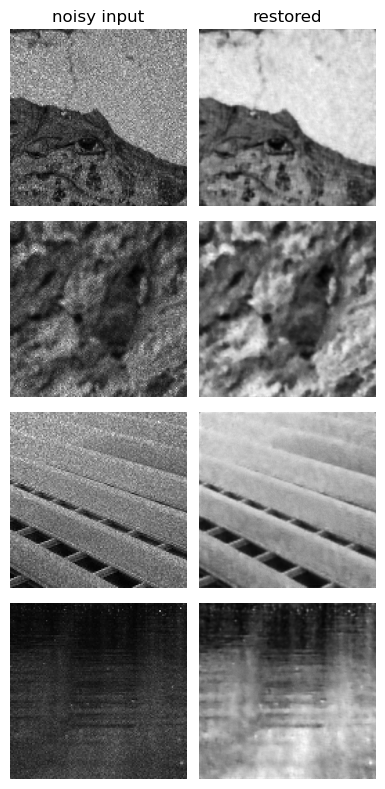

In [ ]:
import matplotlib.pyplot as plt

test_files = sorted(Path(TEST_LR_PATH).glob("*.npy"))[:8]
test_imgs = np.stack([np.load(f) for f in test_files])[..., None].astype(np.float32)  # (N,H,W,1)

# --- preprocessing (outside JIT) ---
noisy = to_device({"noisy_lr": test_imgs})["noisy_lr"]
x_norm = normalizer_fn(noisy, axis=(1, 2))

pred, _z_d = model(x_norm)

n = min(4, len(test_files))
fig, ax = plt.subplots(n, 2, figsize=(4, 2 * n))
for i in range(n):
    ax[i, 0].imshow(noisy[i, ..., 0], cmap="gray")
    ax[i, 1].imshow(pred[i, ..., 0], cmap="gray")
for a, t in zip(ax[0], ["noisy input", "restored"]):
    a.set_title(t)
for a in ax.flat:
    a.axis("off")
plt.tight_layout()
plt.show()


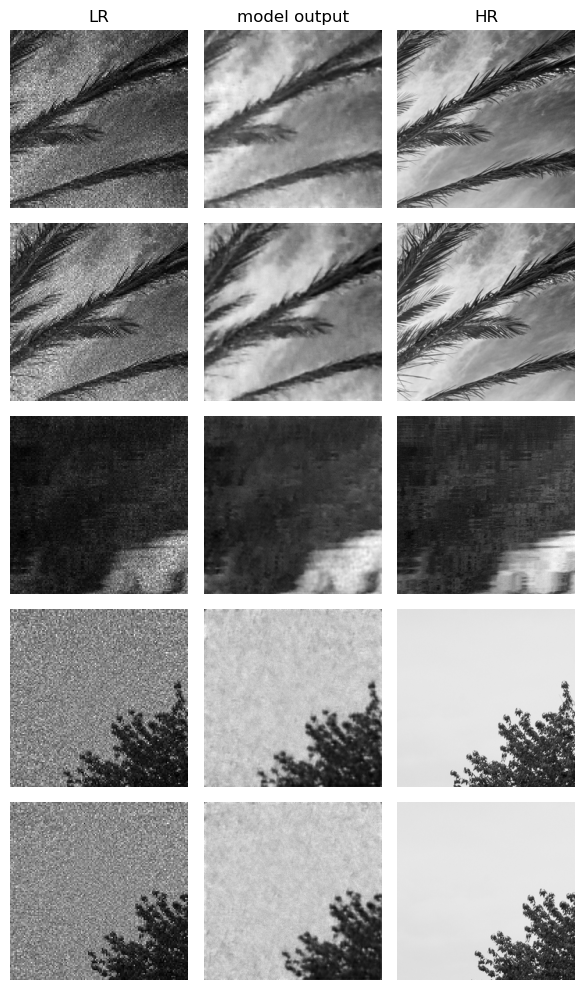

In [ ]:
lr_files = sorted(Path(TRAIN_LR_PATH).glob("*.npy"))[10:15]
gt_files = sorted(Path(TRAIN_GT_PATH).glob("*.npy"))[10:15]

lr_imgs = np.stack([np.load(f) for f in lr_files])[..., None].astype(np.float32)
hr_imgs = np.stack([np.load(f) for f in gt_files])[..., None].astype(np.float32)

# --- preprocessing (outside JIT) ---
lr = to_device({"noisy_lr": lr_imgs})["noisy_lr"]
hr = to_device({"gt": hr_imgs})["gt"]
x_norm = normalizer_fn(lr, axis=(1, 2))

pred, _z_d = model(x_norm)

n = len(lr_files)
fig, ax = plt.subplots(n, 3, figsize=(6, 2 * n))
for i in range(n):
    ax[i, 0].imshow(lr[i, ..., 0], cmap="gray")
    ax[i, 1].imshow(pred[i, ..., 0], cmap="gray")
    ax[i, 2].imshow(hr[i, ..., 0], cmap="gray")
for a, t in zip(ax[0], ["LR", "model output", "HR"]):
    a.set_title(t)
for a in ax.flat:
    a.axis("off")
plt.tight_layout()
plt.show()
